In [1]:
# Notebook used to track specific rays trajectories from raytrace_3d.py

In [2]:
# %matplotlib inline
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import statistics as stats

import particle_tracker as pt
import ray_transfer_matrix as rtm

from PIL import Image, ImageChops
from scipy.spatial import KDTree
import yt.units

{'num_photons': '1000000', 'beam_size': '0.012', 'divergence': '0', 'flash_file': '/scratch/ckuranz_root/ckuranz1/timoney/MagShockZ/simuls/3d_shield_v1/MagShockZ_hdf5_plt_cnt_0019', 'scaling_factor': '0.1', 'output_file': 's10', 'num_processors': '36', 'timestamp': '1775798292.4335597'}


yt : [INFO     ] 2026-06-12 13:35:03,022 Parameters: current_time              = 1.050017964457691e-08
yt : [INFO     ] 2026-06-12 13:35:03,024 Parameters: domain_dimensions         = [384 496 384]
yt : [INFO     ] 2026-06-12 13:35:03,025 Parameters: domain_left_edge          = [-0.8   -0.075 -0.8  ]
yt : [INFO     ] 2026-06-12 13:35:03,027 Parameters: domain_right_edge         = [0.8 2.  0.8]
yt : [INFO     ] 2026-06-12 13:35:03,028 Parameters: cosmological_simulation   = 0
yt : [INFO     ] 2026-06-12 13:35:32,397 xlim = -0.800000 0.800000
yt : [INFO     ] 2026-06-12 13:35:32,399 ylim = -0.075000 2.000000
yt : [INFO     ] 2026-06-12 13:35:32,401 xlim = -0.800000 0.800000
yt : [INFO     ] 2026-06-12 13:35:32,402 ylim = -0.075000 2.000000
yt : [INFO     ] 2026-06-12 13:35:32,406 Making a fixed resolution buffer of (('flash', 'edens')) 800 by 800



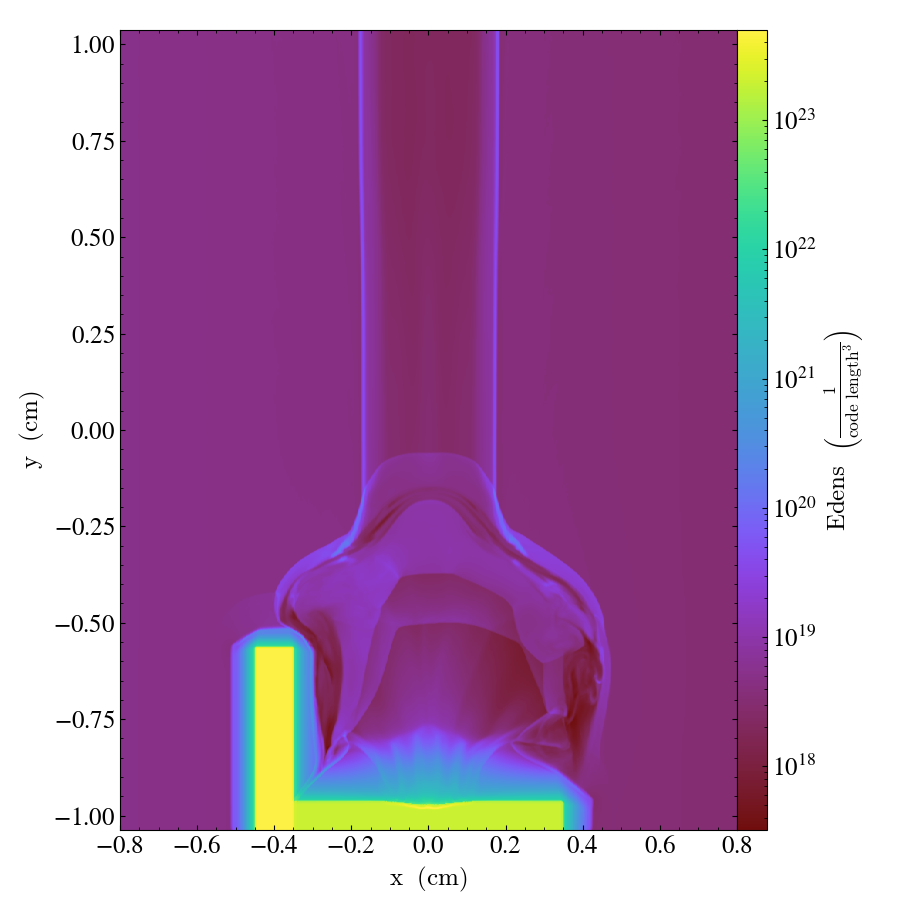

In [3]:
# Get data
ray_trace_dir = '/home/timoney/scratch/timoney/MagShockZ/traces/3d_shield_dens/raytrace_0019_s010'

metadata = {}
raytrace_metadata = ray_trace_dir + '/metadata.txt'
with open(raytrace_metadata, 'r') as f:
    metadata_lines = f.readlines()
    for line in metadata_lines:
        key, value = line.strip().split(': ')
        metadata[key] = value

print(metadata)

ds = yt.load(metadata["flash_file"])

def make_electron_number_density(field, data):
    N_A = yt.units.yt_array.YTQuantity(6.02214076e23, "1/mol")
    proton_mass = yt.units.yt_array.YTQuantity(1.6726219e-24, 'g')
    electron_number_density = N_A*data["flash","dens"]*data["flash","ye"]/proton_mass
    return electron_number_density
ds.add_field(("flash", "edens"), function=make_electron_number_density, units="1/code_length**3",sampling_type="cell") # same here

sl = yt.SlicePlot(ds, 'z', ('flash','edens'))
sl.show()

In [4]:
output_dir = '/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking'
focal_plane = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
focal_plane = focal_plane.v #take out yt unit

print("focal plane [mm]:", focal_plane)


offset_mm = 0 # offset for focusing
Lens_FL = 400
total_dist = 450+3600 # distance from target to first image plane default = 450 + 3600
if Lens_FL == 400:
    d1= 450
elif Lens_FL == 500:
    d1 = 584.3

d2 =total_dist-d1
Lens_Rad = .5*75 # radius of lens

focal plane [mm]: 7.97916678711772


(-6.25, 6.25)

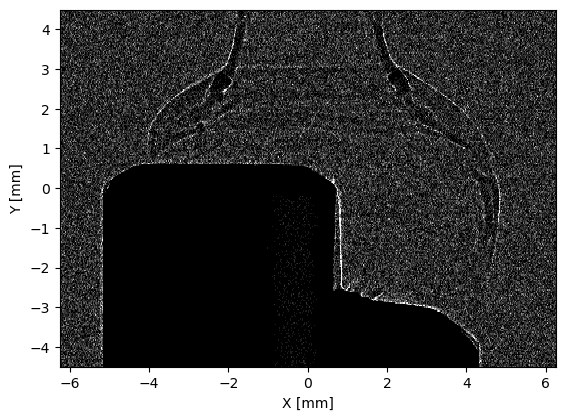

In [43]:
Lens_Rad = 20 # default: 37.5
offset = -4

rf = np.load(f"{ray_trace_dir}/ray_output.npy")
sh = rtm.LIONZ_approx(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad) # must center grid
sh.solve(d1=d1,d2=d2)

sh.histogram(bin_scale = 5)
fig, axs = plt.subplots()
cm='gray'

vmin=np.percentile(sh.H, 5)
vmax=np.percentile(sh.H, 90) #default is 90

clim=(0,vmax*3) # trial and error
sh.plot(axs, cmap=cm, clim=clim)

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
# plt.savefig(f'{output_dir}/{Lens_Rad}mm.png', bbox_inches='tight')
# plt.close()

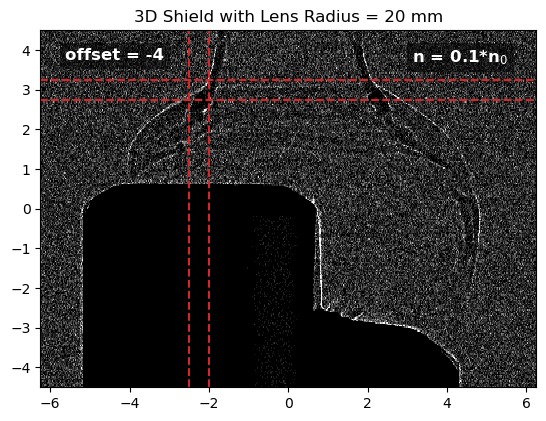

In [44]:
#track rays 
tracker = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad)
tracker.solve(d1, d2)
tracker.histogram(bin_scale = 5)

#define range 
x_upper = -2
x_lower = -2.5
y_upper = 3.25
y_lower= 2.75

# x_upper = 6
# x_lower = -6
# y_upper = 4
# y_lower= -4

fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

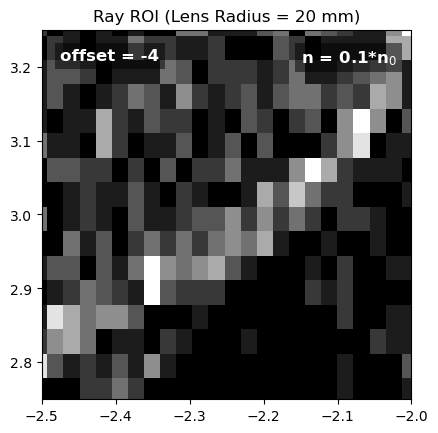

In [45]:
fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

In [46]:
# find rays in region of interest
# between (-3, 2) and (-2, 3) - defined above
tagged_indices = []
for j in range(len(tracker.rf[0, :])):
    if ((tracker.rf[0, j] > x_lower) & (tracker.rf[0, j] < x_upper) & (tracker.rf[2, j] < y_upper) & (tracker.rf[2, j] > y_lower)):
        tagged_indices.append(j)

print('number of tagged rays:', len(tagged_indices))

number of tagged rays: 604


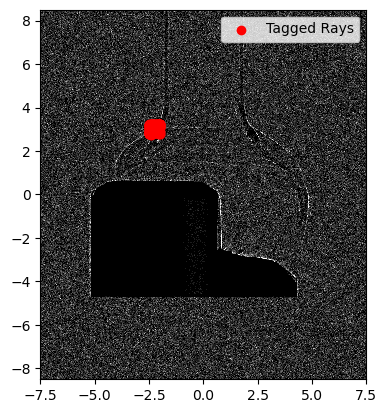

In [47]:
# validate that chosen rays are within the RoI
tracker.histogram(bin_scale=5)

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker.plot(axs, cmap=cm, clim=clim)

tracker.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x_off4 = tracker.rf[0, tagged_indices]
final_y_off4 = tracker.rf[2, tagged_indices]

ax.scatter(final_x_off4, final_y_off4, color='red', label='Tagged Rays')
ax.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

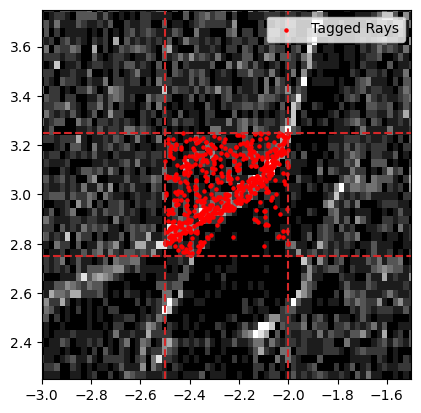

In [59]:
# zoom in on ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error

tracker.plot(ax, clim=clim, cmap=cm)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

ax.scatter(final_x_off4, final_y_off4, color='red', label='Tagged Rays', s = 5)
ax.legend()
plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged_zoom.jpg', bbox_inches='tight')

In [49]:
# get the rays that were cut off by an aperture/optical feature, resulting in NaNs
# get_cut_rays() returns the list of ray arrays that have been cut out and the corresponding z planes they were cut
cut_rays = tracker.get_cut_rays()
print(cut_rays)

# fig, ax = plt.subplots(figsize=(10, 5))
# for tag in cut_rays:
    
#     x_positions = [state[0, tag] for state in tracker.history]
#     ax.plot(tracker.z_planes, x_positions, color='blue', alpha=0.4, linewidth=0.8)

# ax.set_title(f"NaN Rays Trajectories")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
# plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
# plt.legend()
# plt.show()
# plt.ylim(-5,5)

76113 rays filtered out (NaNs)
[    41     43     67 ... 999963 999970 999986]


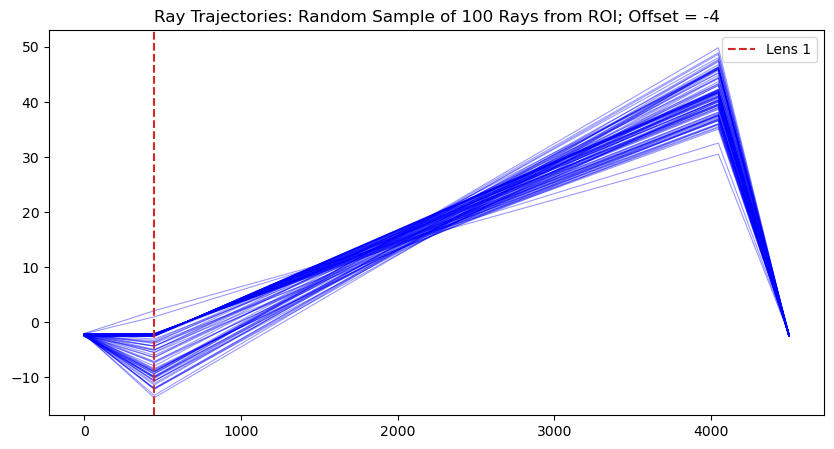

In [50]:
# Randomly select 100 rays from pool of 9000
num_to_plot = 100
sampled_indices = np.random.choice(tagged_indices, size=num_to_plot, replace=False)

fig, ax = plt.subplots(figsize=(10, 5))
for tag in sampled_indices:
    
    x_positions = [state[0, tag] for state in tracker.history]
    ax.plot(tracker.z_planes, x_positions, color='blue', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Random Sample of {num_to_plot} Rays from ROI; Offset = {offset}")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
plt.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_paths.jpg', bbox_inches='tight')
# plt.ylim(-5,5)

In [51]:
# now, run raytracing with offset at 0. check trajectories for all the tagged rays

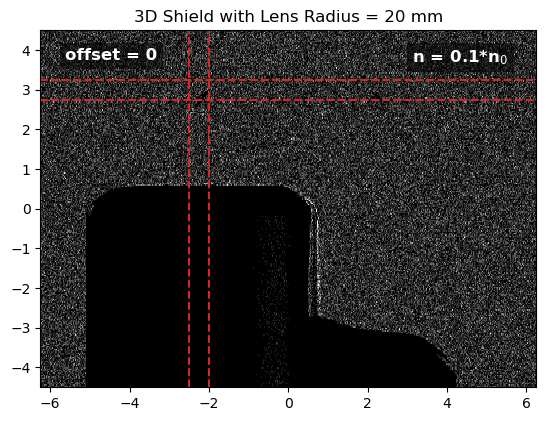

In [52]:
#track rays 
offset = 0
sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
sim_radius=sim_radius.v
tracker_off0 = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = sim_radius+offset, L=Lens_FL, R=Lens_Rad)
tracker_off0.solve(d1, d2)
tracker_off0.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

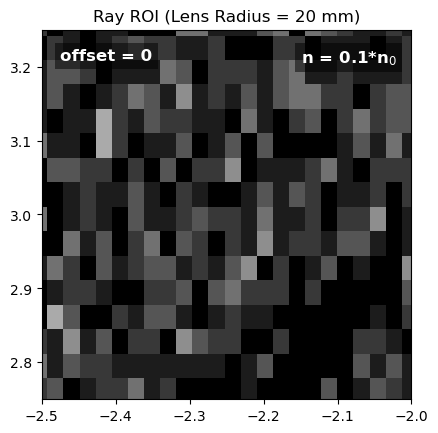

In [53]:
fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)
plt.ylim(y_lower, y_upper)
plt.xlim(x_lower, x_upper)

axs.text(0.7, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.title(f'Ray ROI (Lens Radius = {Lens_Rad} mm)')
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi_zoom.jpg', bbox_inches='tight')

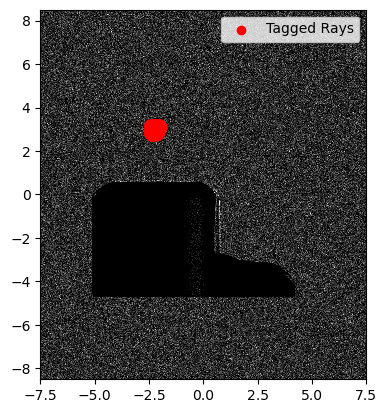

In [54]:
# plot rays that were in original ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_off0.plot(axs, cmap=cm, clim=clim)

tracker_off0.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x = tracker_off0.rf[0, tagged_indices]
final_y = tracker_off0.rf[2, tagged_indices]

#check that no rays are out of the domain
for i in range(len(final_x)):
    if((final_x[i] > 7.5) or (final_x[i] < -7.5) or (final_y[i] > 8) or (final_y[i] < -8)):
        print('Ray', i, 'out of domain')

ax.scatter(final_x, final_y, color='red', label='Tagged Rays')
ax.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged.jpg', bbox_inches='tight')

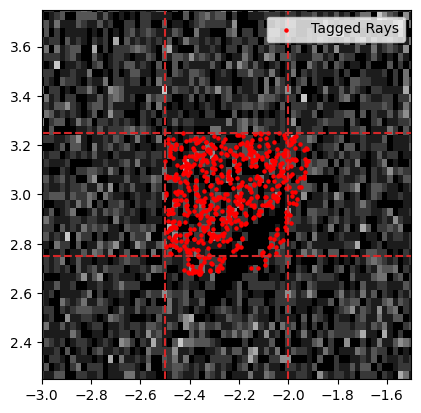

In [55]:
# zoom in on ROI

fig, ax = plt.subplots()
cm='gray'
vmin=np.percentile(tracker.H, 5)
vmax=np.percentile(tracker.H, 90) #default is 90
clim=(0,vmax*3) # trial and error
tracker_off0.plot(axs, cmap=cm, clim=clim)

tracker_off0.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
final_x_off0 = tracker_off0.rf[0, tagged_indices]
final_y_off0 = tracker_off0.rf[2, tagged_indices]

plt.axvline(x_upper, linestyle = '--', color = 'tab:red')
plt.axvline(x_lower, linestyle = '--', color = 'tab:red')
plt.axhline(y_upper, linestyle = '--', color = 'tab:red')
plt.axhline(y_lower, linestyle = '--', color = 'tab:red')

ax.scatter(final_x, final_y, color='red', label='Tagged Rays', s = 5)
ax.legend()
plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_tagged_zoom.jpg', bbox_inches='tight')

In [56]:
#check if there are any rays that are NaN (cut off by optics)
cut_rays_off0 = tracker_off0.get_cut_rays()

overlap = 0
for i in range(len(tagged_indices)):
    if tagged_indices[i] in cut_rays_off0:
        overlap += 1
print('Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI:', overlap)

76057 rays filtered out (NaNs)
Number of rays that were cut off when offset = 0 but not when offset = -4 in ROI: 0


Text(80.34722222222221, 0.5, 'X [mm]')

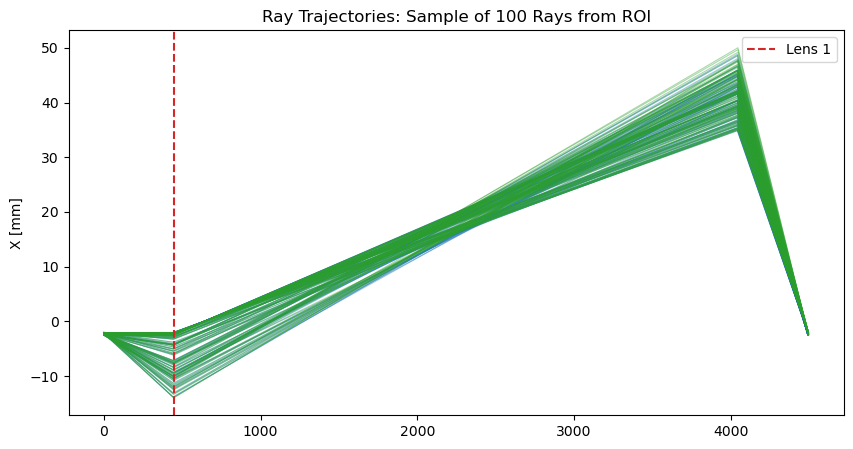

In [173]:
fig, ax = plt.subplots(figsize=(10, 5))
for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker_off0.history]
    if tag == 965585:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8, label = 'Offset = 0 mm')
    else:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8)

for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker.history]
    if tag == 965585:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8, label = 'Offset = -4 mm')
    else:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Sample of {num_to_plot} Rays from ROI")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
plt.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/paths.jpg', bbox_inches='tight')
# plt.ylim(-5,5)
plt.ylabel('X [mm]')

Text(80.34722222222221, 0.5, 'Y [mm]')

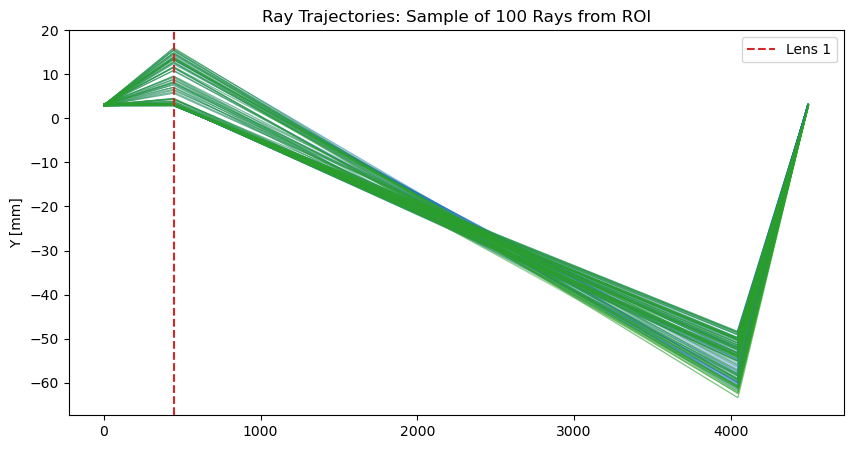

In [175]:
fig, ax = plt.subplots(figsize=(10, 5))
for tag in sampled_indices:
    y_positions = [state[2, tag] for state in tracker_off0.history]
    if tag == 965585:
        ax.plot(tracker_off0.z_planes, y_positions, color='tab:blue', alpha=0.4, linewidth=0.8, label = 'Offset = 0 mm')
    else:
        ax.plot(tracker_off0.z_planes, y_positions, color='tab:blue', alpha=0.4, linewidth=0.8)

for tag in sampled_indices:
    y_positions = [state[2, tag] for state in tracker.history]
    if tag == 965585:
        ax.plot(tracker.z_planes, y_positions, color='tab:green', alpha=0.4, linewidth=0.8, label = 'Offset = -4 mm')
    else:
        ax.plot(tracker.z_planes, y_positions, color='tab:green', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Sample of {num_to_plot} Rays from ROI")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')
plt.legend()
plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/paths.jpg', bbox_inches='tight')
# plt.ylim(-5,5)
plt.ylabel('Y [mm]')

Text(0, 0.5, 'Y [mm]')

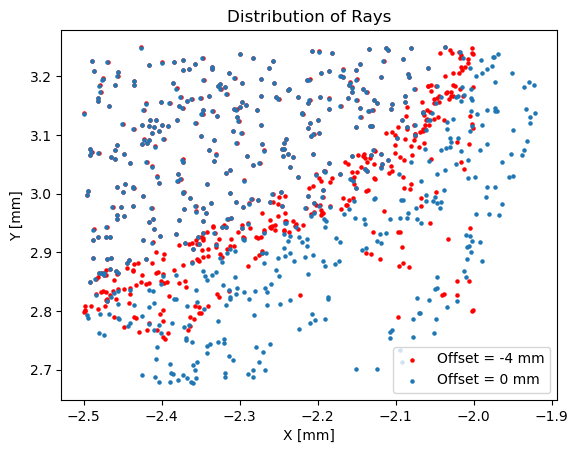

In [58]:
# statistical analysis of the ray distribution
coords4 = np.column_stack((final_x_off4, final_y_off4))
coords0 = np.column_stack((final_x_off0, final_y_off0))

fig, ax = plt.subplots()

ax.scatter(coords4[:,0], coords4[:,1], color='red', label='Offset = -4 mm', s = 5)
ax.scatter(coords0[:,0], coords0[:,1], color='tab:blue', label='Offset = 0 mm', s = 5)

ax.legend()

plt.title('Distribution of Rays')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')

In [21]:
mean4 = np.mean(coords4, axis = 0)
mean0 = np.mean(coords0, axis = 0)

print(f'mean (-4): {mean4}, mean (0): {mean0}')

std4_xy = np.std(coords4, axis = 0)
std0_xy = np.std(coords0, axis = 0)

std4 = np.sqrt(std4_xy[0]**2 + std4_xy[1]**2)
std0 = np.sqrt(std0_xy[0]**2 + std0_xy[1]**2)

print('Standard deviation (x, y) for Offset = -4 mm:', std4_xy)
print('Standard deviation (x, y) for Offset = 0 mm:', std0_xy)

print(f'Total std for Offset = -4 mm: {std4:.3f}')
print(f'Total std for Offset = 0 mm: {std0:.3f}')

mean (-4): [-2.2648743   3.02910959], mean (0): [-2.24531417  3.00133399]
Standard deviation (x, y) for Offset = -4 mm: [0.14683338 0.12982705]
Standard deviation (x, y) for Offset = 0 mm: [0.15721791 0.15331587]
Total std for Offset = -4 mm: 0.196
Total std for Offset = 0 mm: 0.220


Text(0, 0.5, 'Y [mm]')

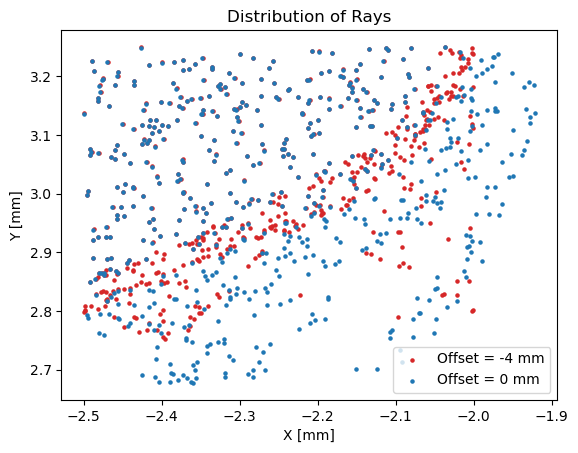

In [22]:
fig, ax = plt.subplots()

plt.scatter(final_x_off4, final_y_off4, color='tab:red', label='Offset = -4 mm', s = 5)
plt.scatter(final_x_off0, final_y_off0, color='tab:blue', label='Offset = 0 mm', s = 5)
# plt.scatter(x_mean_4, y_mean_4, color = 'red', label = 'Mean: Offset = -4 mm', s = 50, marker = 'x')
# plt.scatter(x_mean_0, y_mean_0, color = 'blue', label = 'Mean: Offset = 0 mm', s = 50, marker = 'x')

ax.legend()

plt.title('Distribution of Rays')
plt.xlabel('X [mm]')
plt.ylabel('Y [mm]')

In [23]:
coords_off4 = np.column_stack([final_x_off4, final_y_off4])
coords_off0 = np.column_stack([final_x_off0, final_y_off0])

dists_off4, _ = KDTree(coords_off4).query(coords_off4, k=2)  # k=2: skip self
dists_off0, _ = KDTree(coords_off0).query(coords_off0, k=2)

# Compare mean and CV
print(f'Offset = -4 nearest neighbor mean:{dists_off4[:, 1].mean():.4f}, std: {dists_off4[:, 1].std():.4f}')
print(f'Offset = 0 nearest neighbor mean:{dists_off0[:, 1].mean():.4f}, std: {dists_off0[:, 1].std():.4f}')

Offset = -4 nearest neighbor mean:0.0086, std: 0.0069
Offset = 0 nearest neighbor mean:0.0103, std: 0.0057


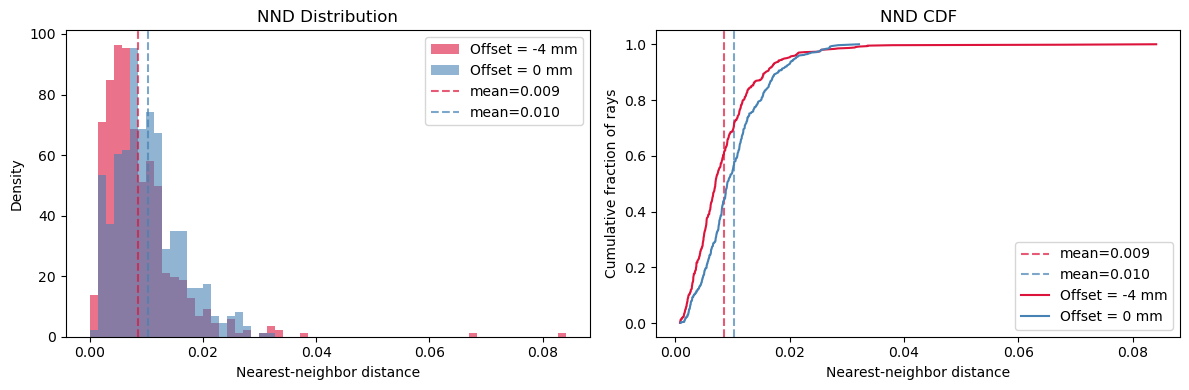

In [30]:
# plot nearest neighbor distribution: CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bins = np.linspace(0, max(dists_off4[:, 1].max(), dists_off0[:, 1].max()), 60)
ax.hist(dists_off4[:, 1], bins=bins, alpha=0.6, label='Offset = -4 mm', color='crimson', density=True)
ax.hist(dists_off0[:, 1], bins=bins, alpha=0.6, label='Offset = 0 mm', color='steelblue', density=True)
for dists, color in [(dists_off4[:, 1], 'crimson'), (dists_off0[:, 1], 'steelblue')]:
    mean = dists.mean()
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7, label=f'mean={mean:.3f}')
ax.set_xlabel('Nearest-neighbor distance')
ax.set_ylabel('Density')
ax.set_title('NND Distribution')
ax.legend()

ax = axes[1]
for dists, color in [(dists_off4[:, 1], 'crimson'), (dists_off0[:, 1], 'steelblue')]:
    mean = dists.mean()
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7, label=f'mean={mean:.3f}')

for dists, label, color in [
    (dists_off4[:, 1], 'Offset = -4 mm', 'crimson'),
    (dists_off0[:, 1], 'Offset = 0 mm', 'steelblue'),]:
    sorted_d = np.sort(dists)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax.plot(sorted_d, cdf, label=label, color=color)
ax.set_xlabel('Nearest-neighbor distance')
ax.set_ylabel('Cumulative fraction of rays')
ax.set_title('NND CDF')
ax.legend()

plt.tight_layout()
plt.show()

In [31]:
# gini coefficient (not helpful)
def gini(arr):
    flat = np.sort(arr.ravel())
    n = len(flat)
    cumsum = np.cumsum(flat)
    return (2 * np.sum((np.arange(1, n+1)) * flat) / (n * cumsum[-1])) - (n + 1) / n

print(gini(tracker.H), gini(tracker_off0.H))

0.5148920358947804 0.5063717625590005


number of tagged rays: 441


Text(0.5, 1.0, '3D Shield with Offset = -4 mm')

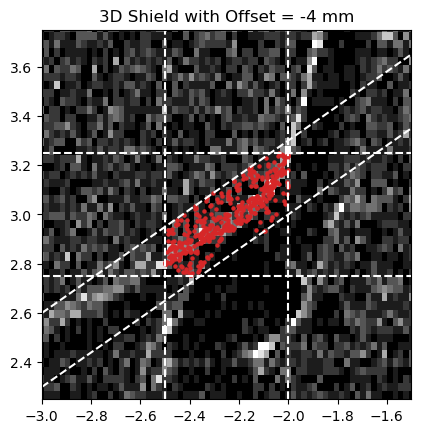

In [64]:
# restrict ROI to cut off outliers
# find rays in region of interest
# between (-3, 2) and (-2, 3) - defined above
# also add in the restriction of a line
tagged_indices = []
m = 0.7
b1 = 4.7
b2 = 4.4
for j in range(len(tracker.rf[0, :])):
    if ((tracker.rf[0, j] > x_lower) & (tracker.rf[0, j] < x_upper) & (tracker.rf[2, j] < y_upper) & (tracker.rf[2, j] > y_lower)
       & (tracker.rf[2, j] < m*tracker.rf[0, j]+b1) & (tracker.rf[2, j] > m*tracker.rf[0, j]+b2)):
        tagged_indices.append(j)

final_x_off4 = tracker.rf[0, tagged_indices]
final_y_off4 = tracker.rf[2, tagged_indices]

print('number of tagged rays:', len(tagged_indices))

#track rays 
fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'white')
plt.axvline(x_lower, linestyle = '--', color = 'white')
plt.axhline(y_upper, linestyle = '--', color = 'white')
plt.axhline(y_lower, linestyle = '--', color = 'white')
x = np.linspace(-3, -1.5, 100)
y1 = m*x+b1
plt.plot(x, y1, color = 'white', linestyle = '--')
y2 = m*x+b2
plt.plot(x, y2, color = 'white', linestyle = '--')

plt.scatter(final_x_off4, final_y_off4, color='tab:red', label='Offset = -4 mm', s = 5)

plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.title(f'3D Shield with Offset = -4 mm')

# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/off={offset}_roi.jpg', bbox_inches='tight')

Text(0.5, 1.0, '3D Shield with Offset = 0 mm')

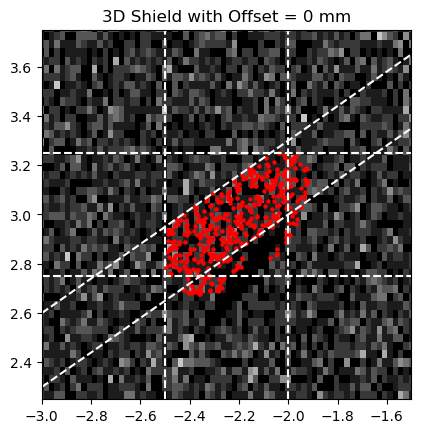

In [65]:
final_x_off0 = tracker_off0.rf[0, tagged_indices]
final_y_off0 = tracker_off0.rf[2, tagged_indices]

fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)

plt.axvline(x_upper, linestyle = '--', color = 'white')
plt.axvline(x_lower, linestyle = '--', color = 'white')
plt.axhline(y_upper, linestyle = '--', color = 'white')
plt.axhline(y_lower, linestyle = '--', color = 'white')
plt.plot(x, y1, color = 'white', linestyle = '--')
plt.plot(x, y2, color = 'white', linestyle = '--')

plt.scatter(final_x_off0, final_y_off0, color='red', label='Offset = 0 mm', s = 5)

plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.title(f'3D Shield with Offset = 0 mm')

Offset = -4 nearest neighbor mean:0.0077, std: 0.0054
Offset = 0 nearest neighbor mean:0.0102, std: 0.0057


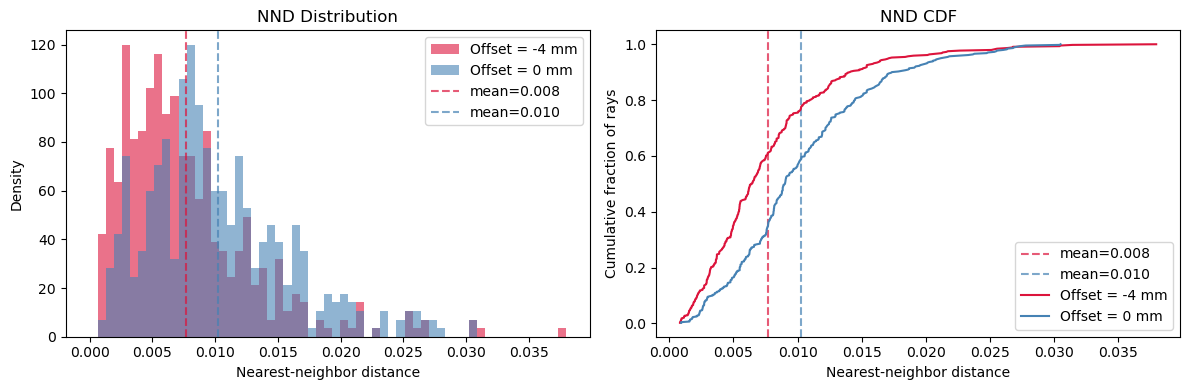

In [66]:
coords_off4 = np.column_stack([final_x_off4, final_y_off4])
coords_off0 = np.column_stack([final_x_off0, final_y_off0])

dists_off4, _ = KDTree(coords_off4).query(coords_off4, k=2)  # k=2: skip self
dists_off0, _ = KDTree(coords_off0).query(coords_off0, k=2)

# Compare mean and CV
print(f'Offset = -4 nearest neighbor mean:{dists_off4[:, 1].mean():.4f}, std: {dists_off4[:, 1].std():.4f}')
print(f'Offset = 0 nearest neighbor mean:{dists_off0[:, 1].mean():.4f}, std: {dists_off0[:, 1].std():.4f}')

# plot nearest neighbor distribution: CDF
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
bins = np.linspace(0, max(dists_off4[:, 1].max(), dists_off0[:, 1].max()), 60)
ax.hist(dists_off4[:, 1], bins=bins, alpha=0.6, label='Offset = -4 mm', color='crimson', density=True)
ax.hist(dists_off0[:, 1], bins=bins, alpha=0.6, label='Offset = 0 mm', color='steelblue', density=True)
for dists, color in [(dists_off4[:, 1], 'crimson'), (dists_off0[:, 1], 'steelblue')]:
    mean = dists.mean()
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7, label=f'mean={mean:.3f}')
ax.set_xlabel('Nearest-neighbor distance')
ax.set_ylabel('Density')
ax.set_title('NND Distribution')
ax.legend()

ax = axes[1]
for dists, color in [(dists_off4[:, 1], 'crimson'), (dists_off0[:, 1], 'steelblue')]:
    mean = dists.mean()
    ax.axvline(mean, color=color, linestyle='--', alpha=0.7, label=f'mean={mean:.3f}')

for dists, label, color in [
    (dists_off4[:, 1], 'Offset = -4 mm', 'crimson'),
    (dists_off0[:, 1], 'Offset = 0 mm', 'steelblue'),]:
    sorted_d = np.sort(dists)
    cdf = np.arange(1, len(sorted_d) + 1) / len(sorted_d)
    ax.plot(sorted_d, cdf, label=label, color=color)
ax.set_xlabel('Nearest-neighbor distance')
ax.set_ylabel('Cumulative fraction of rays')
ax.set_title('NND CDF')
ax.legend()

plt.tight_layout()
plt.show()

## Image rays at the fromt of the simulation

overlapping: matches what we expect!


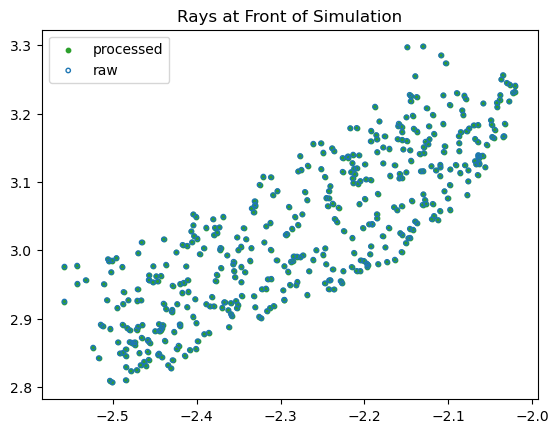

In [149]:
#set propagation distance equal to the focal plane because 0 is defined as the midplane

rays_simfront = rtm.LIONZ_image_sweep(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane, L=Lens_FL, R=Lens_Rad)
rays_simfront.solve(d1, d2, intermed_dist=focal_plane)
rays_simfront.histogram(bin_scale = 5)

rays_simfront.plot(ax, clim=clim, cmap=cm)

# get final x and y coordinates for tracked rays
rays_simfront_x = rays_simfront.rf[0, tagged_indices]
rays_simfront_y = rays_simfront.rf[2, tagged_indices]

rays_raw_x = rf[0, tagged_indices] * 1000
rays_raw_y = rf[2, tagged_indices] * 1000

plt.scatter(rays_simfront_x, rays_simfront_y, s = 10, color = 'tab:green', label = 'processed')
plt.scatter(rays_raw_x, rays_raw_y, s = 10, color = 'tab:blue',facecolor = 'none', label = 'raw')
plt.title('Rays at Front of Simulation')

plt.legend()

print('overlapping: matches what we expect!')

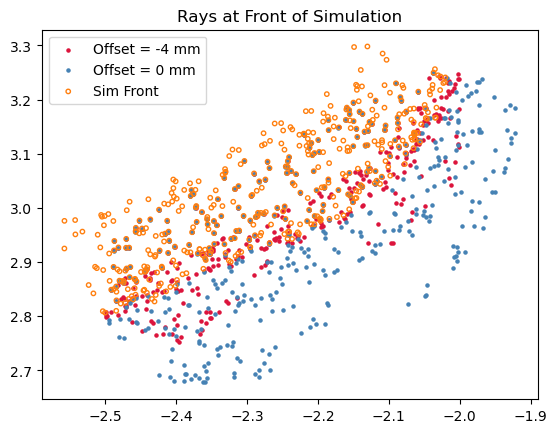

this shift upwards makes sense because of the paths the rays are taking through space: negative offset = moving upwards in y direction for this region


In [177]:
fig, axs = plt.subplots()
plt.scatter(final_x_off4, final_y_off4, color='crimson', label='Offset = -4 mm', s = 5)
plt.scatter(final_x_off0, final_y_off0, color='steelblue', label='Offset = 0 mm', s = 5)
plt.scatter(rays_simfront_x, rays_simfront_y, s = 10, facecolor = 'none', color = 'tab:orange', label = 'Sim Front')

plt.title('Rays at Front of Simulation')
plt.legend()
plt.show()

print('this shift upwards makes sense because of the paths the rays are taking through space: negative offset = moving upwards in y direction for this region')

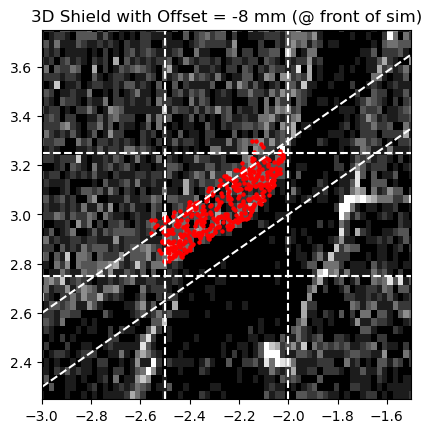

In [166]:
# try setting offset to be equal to FP: what happens?
tracker_fp = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = sim_radius-sim_radius, L=Lens_FL, R=Lens_Rad)
tracker_fp.solve(d1, d2)
tracker_fp.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker_fp.plot(axs, cmap=cm, clim=clim)

# get final x and y coordinates for tracked rays
rays_fp_x = tracker_fp.rf[0, tagged_indices]
rays_fp_y = tracker_fp.rf[2, tagged_indices]
plt.axvline(x_upper, linestyle = '--', color = 'white')
plt.axvline(x_lower, linestyle = '--', color = 'white')
plt.axhline(y_upper, linestyle = '--', color = 'white')
plt.axhline(y_lower, linestyle = '--', color = 'white')

plt.plot(x, y1, color = 'white', linestyle = '--')
plt.plot(x, y2, color = 'white', linestyle = '--')

plt.scatter(rays_fp_x, rays_fp_y, color = 'red', s = 5, label = f'Offset = {sim_radius:.2f} mm')
plt.xlim(-3, -1.5)
plt.ylim(2.25,3.75)
plt.title('3D Shield with Offset = -8 mm (@ front of sim)')
plt.show()

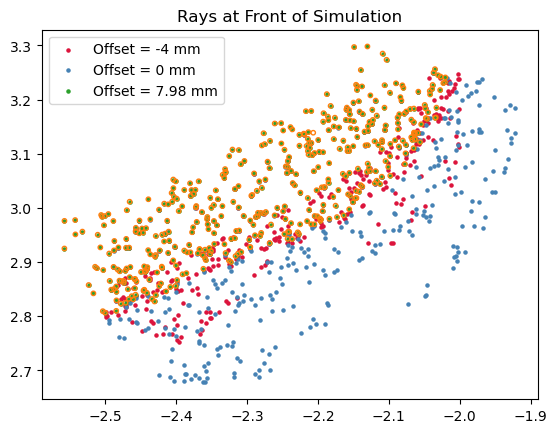

In [156]:
fig, axs = plt.subplots()
plt.scatter(final_x_off4, final_y_off4, color='crimson', label='Offset = -4 mm', s = 5)
plt.scatter(final_x_off0, final_y_off0, color='steelblue', label='Offset = 0 mm', s = 5)
plt.scatter(rays_fp_x, rays_fp_y, color = 'tab:green', s = 5, label = f'Offset = {sim_radius:.2f} mm')
plt.scatter(rays_simfront_x, rays_simfront_y, s = 10, facecolor = 'none', color = 'tab:orange')

plt.title('Rays at Front of Simulation')
plt.legend()
plt.show()

## Analyze region of bright spots based on measured brightness

Text(0.5, 1.0, '3D Shield with Lens Radius = 20 mm')

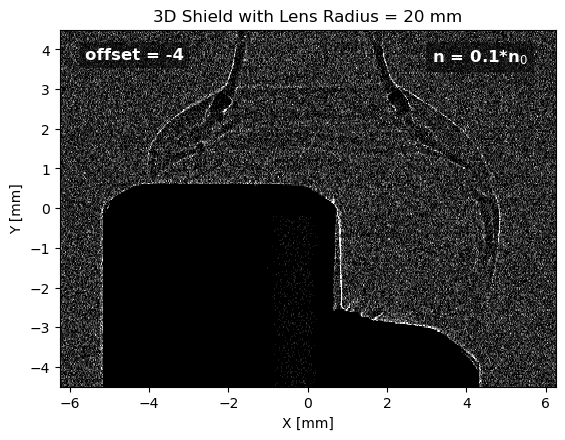

In [34]:
#track rays 
offset = -4 
tracker = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = focal_plane+offset, L=Lens_FL, R=Lens_Rad)
tracker.solve(d1, d2)
tracker.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

scale = 0.1
axs.text(0.75, 0.95, f'n = {scale}*n$_0$', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))
axs.text(0.05, 0.95, f'offset = {offset}', 
     transform=axs.transAxes, 
     color='white', 
     fontsize=12, 
     fontweight='bold',
     verticalalignment='top',
     bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'))

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.title(f'3D Shield with Lens Radius = {Lens_Rad} mm')

In [35]:
threshold = np.percentile(tracker.H, 99.9)
bright_bins = np.argwhere(tracker.H > threshold)

x_edges = tracker.xedges
y_edges = tracker.yedges

#get bin coordinates and limits
bright_spot_coords = []
for (row_idx, col_idx) in bright_bins:
    pass_mask = True
    x_lo, x_hi = x_edges[col_idx], x_edges[col_idx + 1]
    y_lo, y_hi = y_edges[row_idx], y_edges[row_idx + 1]
    if((y_lo < 0.7) & (x_lo < 1)):
        pass_mask = False
    if(y_lo < -2):
        pass_mask = False
    if(pass_mask == True):
        bright_spot_coords.append((x_lo, x_hi, y_lo, y_hi))

In [69]:
ray_x = tracker.rf[0, :]  # shape (999990,)
ray_y = tracker.rf[2, :]  # shape (999990,)

bright_spot_mask = np.zeros(ray_x.shape[0], dtype=bool)  # correct size now

for (x_lo, x_hi, y_lo, y_hi) in bright_spot_coords:
    in_bin = (ray_x >= x_lo) & (ray_x < x_hi) & (ray_y >= y_lo) & (ray_y < y_hi)
    bright_spot_mask |= in_bin

bs_indices = np.where(bright_spot_mask)[0]
print('number of tagged rays:', len(bs_indices))

number of tagged rays: 1468


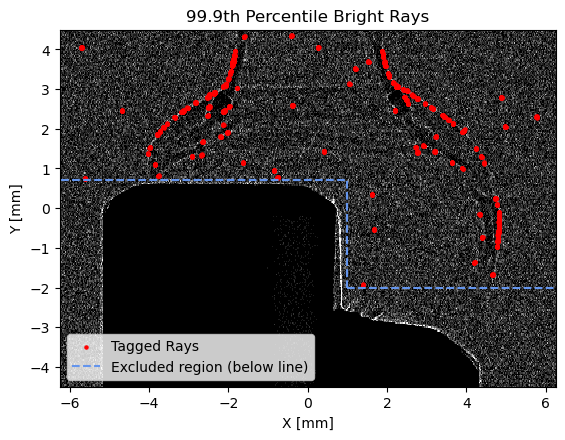

In [70]:
fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

bs_x_o4 = tracker.rf[0, bs_indices]
bs_y_o4 = tracker.rf[2, bs_indices]

axs.scatter(bs_x_o4, bs_y_o4, color='red', label='Tagged Rays', s = 5)

plt.vlines(x=1, ymin=-2, ymax=0.7, color='cornflowerblue', linestyle = '--')
plt.hlines(y=-2, xmin=1, xmax=6.5, color = 'cornflowerblue', linestyle='--')
plt.hlines(y=0.7, xmin=-6.5, xmax=1, color = 'cornflowerblue', linestyle='--', label = 'Excluded region (below line)')

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.legend()
plt.title('99.9th Percentile Bright Rays')
plt.savefig(f'{output_dir}/bs_999_shieldselected.png', bbox_inches='tight')
# plt.close() 

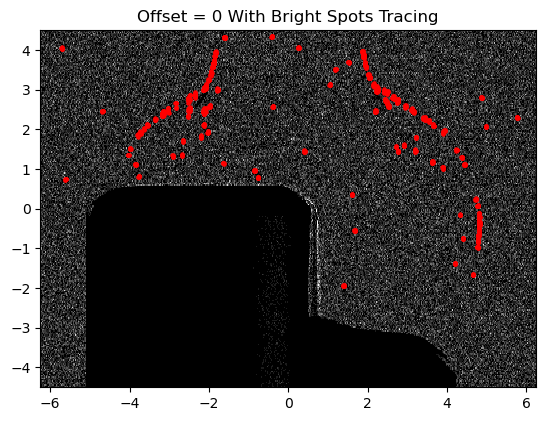

In [71]:
offset = 0
sim_radius = (ds.r[('flash','z')][-1]-ds.r[('flash','z')][0])/2*10 # midplane of simulation (multiply by 10 to convert to mm)
sim_radius=sim_radius.v
tracker_off0 = rtm.Tracked_Shadowgraphy(r0 = rf, Lx = 15, Ly = 17, focal_plane = sim_radius+offset, L=Lens_FL, R=Lens_Rad)
tracker_off0.solve(d1, d2)
tracker_off0.histogram(bin_scale = 5)

fig, axs = plt.subplots()
tracker_off0.plot(axs, cmap=cm, clim=clim)

# get final x and y coordinates for tracked rays
bs_x_o0 = tracker_off0.rf[0, bs_indices]
bs_y_o0 = tracker_off0.rf[2, bs_indices]

#check that no rays are out of the domain
for i in range(len(final_x)):
    if((final_x[i] > 7.5) or (final_x[i] < -7.5) or (final_y[i] > 8) or (final_y[i] < -8)):
        print('Ray', i, 'out of domain')

axs.scatter(bs_x_o4, bs_y_o0, color='red', label='Tagged Rays', s = 5)

plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.title(f'Offset = 0 With Bright Spots Tracing')

plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/bs_off0.jpg', bbox_inches='tight')

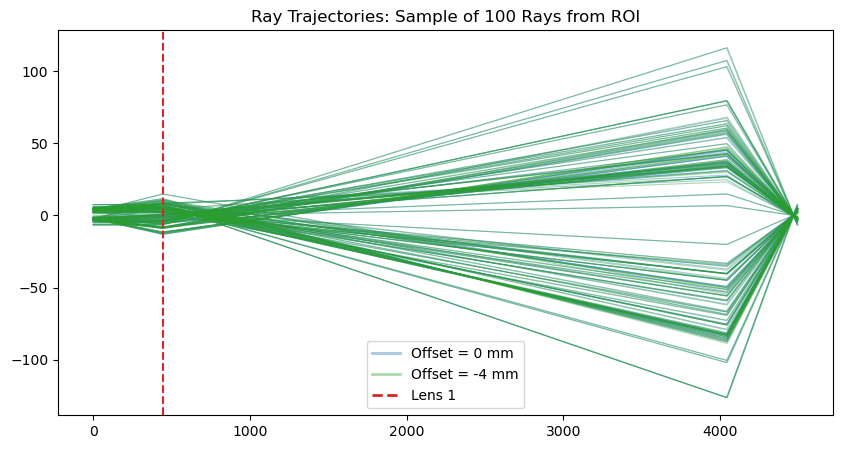

In [76]:
fig, ax = plt.subplots(figsize=(10, 5))
sampled_indices = np.random.choice(bs_indices, size=100, replace=False)

c = 0
for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker_off0.history]
    if c == 0:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8, label = 'Offset = 0 mm')
        c+=1
    else:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8)

c = 0
for tag in sampled_indices:
    x_positions = [state[0, tag] for state in tracker.history]
    if c == 0:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8, label = 'Offset = -4 mm')
        c+=1
    else:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories: Sample of 100 Rays from ROI")
# plt.ylim(-15,15)
# plt.xlim(0,1000)
# plt.ylim(-5,5)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')

leg = ax.legend()
for line in leg.get_lines():
    line.set_linewidth(2.0)
    
# plt.legend()
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/paths.jpg', bbox_inches='tight')

In [77]:
#look at more specific region of interest: left side of the bright spot

#get bin coordinates and limits
bright_spot_coords_r1 = []
for (row_idx, col_idx) in bright_bins:
    pass_mask = True
    x_lo, x_hi = x_edges[col_idx], x_edges[col_idx + 1]
    y_lo, y_hi = y_edges[row_idx], y_edges[row_idx + 1]
    if((y_lo > 0.7) & (x_hi < -1) & (x_lo > -4.5)):
        bright_spot_coords_r1.append((x_lo, x_hi, y_lo, y_hi))

ray_x = tracker.rf[0, :]  # shape (999990,)
ray_y = tracker.rf[2, :]  # shape (999990,)

bright_spot_mask = np.zeros(ray_x.shape[0], dtype=bool)  # correct size now

for (x_lo, x_hi, y_lo, y_hi) in bright_spot_coords_r1:
    in_bin = (ray_x >= x_lo) & (ray_x < x_hi) & (ray_y >= y_lo) & (ray_y < y_hi)
    bright_spot_mask |= in_bin

bs_indices_r1 = np.where(bright_spot_mask)[0]
print('number of tagged rays:', len(bs_indices_r1))

number of tagged rays: 531


Text(0.5, 1.0, 'Bright Rays in R1')

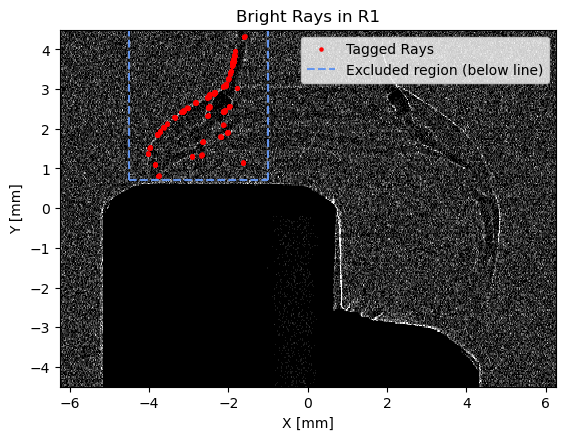

In [82]:
fig, axs = plt.subplots()
tracker.plot(axs, cmap=cm, clim=clim)

bs_x_r1_off4 = tracker.rf[0, bs_indices_r1]
bs_y_r1_off4 = tracker.rf[2, bs_indices_r1]

bs_x_r1_off0 = tracker_off0.rf[0, bs_indices_r1]
bs_y_r1_off0 = tracker_off0.rf[2, bs_indices_r1]

axs.scatter(bs_x_r1_off4, bs_y_r1_off4, color='red', label='Tagged Rays', s = 5)

plt.vlines(x=-1, ymin=0.7, ymax=4.5, color='cornflowerblue', linestyle = '--')
plt.vlines(x=-4.5, ymin=0.7, ymax=4.5, color = 'cornflowerblue', linestyle='--')
plt.hlines(y=0.7, xmin=-4.5, xmax=-1, color = 'cornflowerblue', linestyle='--', label = 'Excluded region (below line)')

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(-4.5, 4.5)
plt.xlim(-6.25, 6.25)
plt.legend()
plt.title('Bright Rays in R1')
# plt.savefig(f'{output_dir}/bs_999_shieldselected.png', bbox_inches='tight')
# plt.close() 

Text(0.5, 1.0, 'Bright Rays in R1')

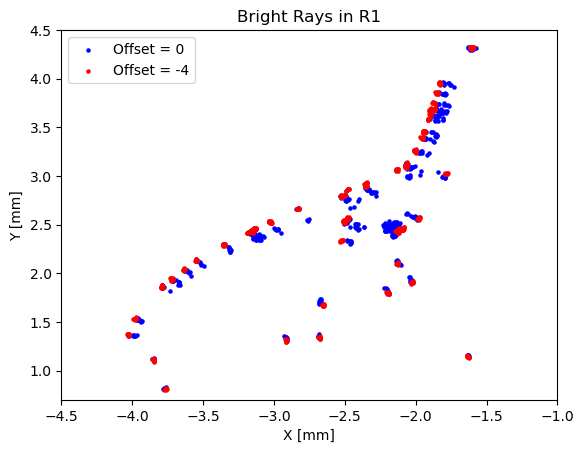

In [84]:
fig, axs = plt.subplots()
axs.scatter(bs_x_r1_off0, bs_y_r1_off0, color='blue', label='Offset = 0', s = 5)
axs.scatter(bs_x_r1_off4, bs_y_r1_off4, color='red', label='Offset = -4', s = 5)

plt.ylabel('Y [mm]')
plt.xlabel('X [mm]')
plt.ylim(0.7, 4.5)
plt.xlim(-4.5, -1)
plt.legend()
plt.title('Bright Rays in R1')
# plt.savefig(f'{output_dir}/bs_999_shieldselected.png', bbox_inches='tight')
# plt.close() 

Text(0, 0.5, 'X [mm]')

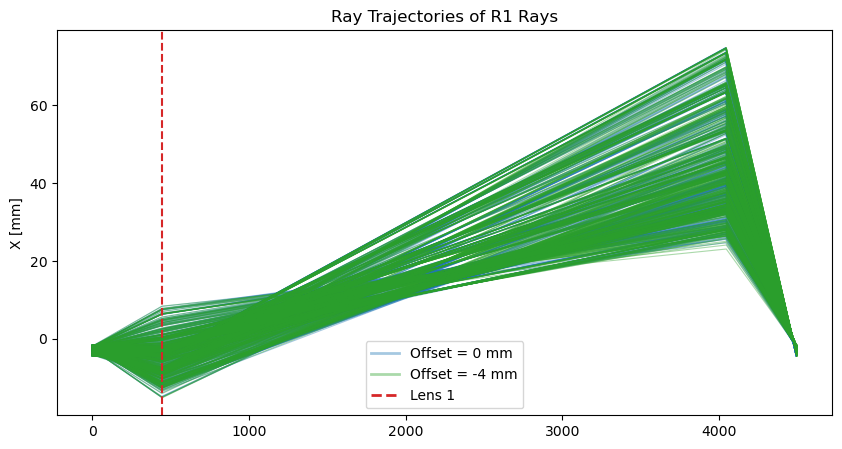

In [86]:
fig, ax = plt.subplots(figsize=(10, 5))

c = 0
for tag in bs_indices_r1:
    x_positions = [state[0, tag] for state in tracker_off0.history]
    if c == 0:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8, label = 'Offset = 0 mm')
        c+=1
    else:
        ax.plot(tracker_off0.z_planes, x_positions, color='tab:blue', alpha=0.4, linewidth=0.8)

c = 0
for tag in bs_indices_r1:
    x_positions = [state[0, tag] for state in tracker.history]
    if c == 0:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8, label = 'Offset = -4 mm')
        c+=1
    else:
        ax.plot(tracker.z_planes, x_positions, color='tab:green', alpha=0.4, linewidth=0.8)

ax.set_title(f"Ray Trajectories of R1 Rays")
# plt.ylim(-15,15)
# plt.xlim(-7,10)
# plt.ylim(-5,0)
plt.axvline(d1-(focal_plane/2), linestyle = '--', color = 'tab:red', label = 'Lens 1')

leg = ax.legend()
for line in leg.get_lines():
    line.set_linewidth(2.0)
plt.ylabel('X [mm]')
# plt.legend()
# plt.savefig(f'/home/timoney/scratch/timoney/MagShockZ/images/ray_tracking/paths.jpg', bbox_inches='tight')